# nuPlan Mini Transfer Benchmark for FM + CBF

- 场景：`following_lane_without_lead` (lane_following) + `starting_left_turn` (left_turn)
- 方法：FM+CBF | Pure FM | IDM-proxy
- 指标：time_to_goal | collision_rate | goal_reached | min_inter_agent_dist | road_boundary_violations
- 可视化：轨迹图（论文 Fig3 风格）+ metrics 柱状图

In [1]:
from __future__ import annotations

import math
import random
import sqlite3
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import torch
from IPython.display import Image, display

# ── paths ──────────────────────────────────────────────────────────────
ROOT         = Path('/new_world/cockatiel/ra').resolve()
PROJECT_ROOT = ROOT / 'safeflow-nuplan-transfer' / 'dmpc_fm_cbf'
DATA_ROOT    = ROOT / 'data' / 'cache' / 'mini'
MAP_ROOT     = ROOT / 'maps'
OUTPUT_DIR   = PROJECT_ROOT / 'notebooks' / 'cache' / 'nuplan_transfer'
CKPT_PATH    = PROJECT_ROOT / 'notebooks' / 'cache' / 'model_vel_5ch_canonical_r.pt'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

import sys
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ── model imports ──────────────────────────────────────────────────────
# Try both import paths
try:
    from fmtorch.models.simple1d_unet import SimpleUNet1D
except ImportError:
    from dmpc_fm_cbf.model import SimpleUNet1D

try:
    from dmpc_fm_cbf.canonical import build_can_tf_5d
except ImportError:
    # fallback: inline canonical frame builder
    def build_can_tf_5d(start_xy, goal_xy):
        s = np.asarray(start_xy, np.float32).reshape(2)
        g = np.asarray(goal_xy,  np.float32).reshape(2)
        d = g - s
        dist = float(np.linalg.norm(d) + 1e-9)
        c, sv = d[0]/dist, d[1]/dist
        phi = math.atan2(float(sv), float(c))
        R = np.array([[c, sv], [-sv, c]], np.float32)
        def w2c(xy): return (np.asarray(xy, np.float32).reshape(-1,2) - s) @ R.T
        def c2w(xy): return np.asarray(xy, np.float32).reshape(-1,2) @ R + s
        return dict(w2c=w2c, c2w=c2w, phi=phi, dist=dist,
                    start_can=np.zeros(2,np.float32),
                    goal_can=np.array([dist,0.],np.float32))

from dmpc_fm_cbf.sampler_5h import piecewise_sample_fm_5ch_with_cbf

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('DEVICE    =', DEVICE)
print('DATA_ROOT =', DATA_ROOT)
print('CKPT_PATH =', CKPT_PATH)
print('ckpt exists:', CKPT_PATH.exists())


DEVICE    = cuda
DATA_ROOT = /new_world/cockatiel/ra/data/cache/mini
CKPT_PATH = /new_world/cockatiel/ra/safeflow-nuplan-transfer/dmpc_fm_cbf/notebooks/cache/model_vel_5ch_canonical_r.pt
ckpt exists: True


In [2]:
@dataclass
class BenchmarkConfig:
    seed: int = 7
    scenarios_per_type: int = 8
    episode_steps: int = 200
    horizon_steps: int = 16
    replay_dt_fallback: float = 0.1
    max_agents: int = 8
    goal_tol_m: float = 8.0
    safe_radius_m: float = 3.0
    road_half_width_m: float = 4.5
    road_margin_m: float = 0.5
    idm_desired_speed_mps: float = 8.0
    fm_noise_scale: float = 1.0
    fm_num_segments: int = 20
    fm_tau0: float = 0.50
    fm_tau1: float = 0.90
    fm_goal_guidance_weight: float = 1.20
    fm_start_guidance_weight: float = 0.40
    cbf_extra_margin_m: float = 0.25
    cbf_alpha: float = 8.0
    cbf_max_corr_norm: float = 2.0
    methods: Tuple[str, ...] = ('fm_cbf', 'pure_fm', 'idm_proxy')
    scenario_type_map: Dict[str, str] = None
    model_ckpt: Path = CKPT_PATH   # ← 已指向正确路径

    def __post_init__(self):
        if self.scenario_type_map is None:
            self.scenario_type_map = {
                'lane_following': 'following_lane_without_lead',
                'left_turn':      'starting_left_turn',
            }


@dataclass
class ScenarioRecord:
    db_path: Path
    scene_token: bytes
    anchor_lidar_pc_token: bytes
    goal_ego_pose_token: Optional[bytes]
    scenario_tag: str
    paper_bucket: str
    scene_name: str
    location: str
    map_version: str


@dataclass
class EpisodeMetrics:
    method: str
    paper_bucket: str
    scenario_tag: str
    scene_name: str
    time_to_goal_s: float
    goal_reached: int
    collision: int
    min_inter_agent_dist_m: float
    road_boundary_violations: int
    final_dist_to_goal_m: float
    num_steps: int


CFG = BenchmarkConfig()
random.seed(CFG.seed)
np.random.seed(CFG.seed)
torch.manual_seed(CFG.seed)
CFG


BenchmarkConfig(seed=7, scenarios_per_type=8, episode_steps=200, horizon_steps=16, replay_dt_fallback=0.1, max_agents=8, goal_tol_m=8.0, safe_radius_m=3.0, road_half_width_m=4.5, road_margin_m=0.5, idm_desired_speed_mps=8.0, fm_noise_scale=1.0, fm_num_segments=20, fm_tau0=0.5, fm_tau1=0.9, fm_goal_guidance_weight=1.2, fm_start_guidance_weight=0.4, cbf_extra_margin_m=0.25, cbf_alpha=8.0, cbf_max_corr_norm=2.0, methods=('fm_cbf', 'pure_fm', 'idm_proxy'), scenario_type_map={'lane_following': 'following_lane_without_lead', 'left_turn': 'starting_left_turn'}, model_ckpt=PosixPath('/new_world/cockatiel/ra/safeflow-nuplan-transfer/dmpc_fm_cbf/notebooks/cache/model_vel_5ch_canonical_r.pt'))

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


In [3]:
def blob_hex(blob):
    return None if blob is None else blob.hex()

def wrap_pi(angle):
    return float((angle + np.pi) % (2*np.pi) - np.pi)

def yaw_from_quaternion(qw, qx, qy, qz):
    siny = 2.0*(qw*qz + qx*qy)
    cosy = 1.0 - 2.0*(qy*qy + qz*qz)
    return float(np.arctan2(siny, cosy))

def polyline_distance(point_xy, polyline_xy):
    p   = np.asarray(point_xy, np.float64).reshape(2)
    pts = np.asarray(polyline_xy, np.float64)
    if len(pts) == 0: return float('inf')
    if len(pts) == 1: return float(np.linalg.norm(p - pts[0]))
    best = float('inf')
    for a, b in zip(pts[:-1], pts[1:]):
        ab = b - a; denom = float(np.dot(ab,ab))
        if denom < 1e-9:
            d = np.linalg.norm(p - a)
        else:
            t = np.clip(np.dot(p-a, ab)/denom, 0., 1.)
            d = np.linalg.norm(p - (a + t*ab))
        best = min(best, float(d))
    return best

def nearest_agent_distance(ego_xy, agents):
    if not agents: return float('inf')
    return float(min(np.linalg.norm(ego_xy - a['xy']) for a in agents))

def select_nearest_agents(ego_xy, agents, k):
    return sorted(agents, key=lambda a: np.linalg.norm(a['xy']-ego_xy))[:k]

def make_runtime_state(frame, prev_state=None):
    x, y = float(frame['ego_x']), float(frame['ego_y'])
    theta = float(frame['ego_yaw'])
    v = float(math.hypot(frame['ego_vx'], frame['ego_vy']))
    yr = 0.0 if prev_state is None else wrap_pi(theta - float(prev_state[2])) / max(frame['dt'], 1e-3)
    return np.array([x, y, theta, v, yr], np.float32)

def rollout_point_mass_to_target(state, target_xy, dt, speed_cap):
    xy = state[:2].astype(np.float64)
    tgt = np.asarray(target_xy, np.float64).reshape(2)
    delta = tgt - xy; dist = float(np.linalg.norm(delta))
    if dist < 1e-6: return state.copy()
    d = delta/dist; speed = min(speed_cap, dist/max(dt,1e-3))
    next_xy = xy + d*speed*dt
    theta = float(np.arctan2(d[1], d[0]))
    yr = wrap_pi(theta - float(state[2]))/max(dt,1e-3)
    return np.array([next_xy[0], next_xy[1], theta, speed, yr], np.float32)


def load_model(cfg):
    if not Path(cfg.model_ckpt).exists():
        print(f'[WARN] checkpoint not found: {cfg.model_ckpt}')
        return None
    model = SimpleUNet1D(cond_dim=5, hidden_dim=128, in_channels=5, out_channels=5)
    ckpt  = torch.load(cfg.model_ckpt, map_location=DEVICE)
    state = ckpt.get('model_state_dict', ckpt)
    ckpt_in = state.get('conv_in.weight')
    ckpt_out = state.get('conv_out.2.weight')
    ckpt_in_ch = None if ckpt_in is None else int(ckpt_in.shape[1])
    ckpt_out_ch = None if ckpt_out is None else int(ckpt_out.shape[0])
    if ckpt_in_ch != model.in_channels or ckpt_out_ch != model.out_channels:
        raise ValueError(
            f'Checkpoint channel mismatch for {cfg.model_ckpt}: '
            f'checkpoint is {ckpt_in_ch}->{ckpt_out_ch} channels, '
            f'but MODEL_5CH expects {model.in_channels}->{model.out_channels}. '
            'Use notebooks/cache/model_vel_5ch_canonical_r.pt for the 5-channel model.'
        )
    model.load_state_dict(state)
    model = model.to(DEVICE).eval()
    print(f'[OK] model loaded from {cfg.model_ckpt}')
    return model


MODEL_5CH = load_model(CFG)


[OK] model loaded from /new_world/cockatiel/ra/safeflow-nuplan-transfer/dmpc_fm_cbf/notebooks/cache/model_vel_5ch_canonical_r.pt


In [4]:
def discover_scenarios(cfg):
    records = []
    db_files = sorted(DATA_ROOT.glob('*.db'))
    print(f'found {len(db_files)} mini db files')
    for db_path in db_files:
        try:
            with sqlite3.connect(str(db_path)) as con:
                cur = con.cursor()
                log_row = cur.execute('SELECT location, map_version FROM log LIMIT 1').fetchone()
                location, map_version = log_row if log_row else ('unknown','unknown')
                for bucket, tag in cfg.scenario_type_map.items():
                    rows = cur.execute('''
                        SELECT DISTINCT lp.scene_token, st.lidar_pc_token,
                               s.goal_ego_pose_token, s.name, st.type
                        FROM scenario_tag st
                        JOIN lidar_pc lp ON st.lidar_pc_token = lp.token
                        JOIN scene s ON lp.scene_token = s.token
                        WHERE st.type = ?
                        ORDER BY s.name
                    ''', (tag,)).fetchall()
                    for scene_token, anchor_token, goal_token, scene_name, sc_tag in rows:
                        records.append(ScenarioRecord(
                            db_path=db_path, scene_token=scene_token,
                            anchor_lidar_pc_token=anchor_token,
                            goal_ego_pose_token=goal_token,
                            scenario_tag=sc_tag, paper_bucket=bucket,
                            scene_name=scene_name, location=location,
                            map_version=map_version))
        except sqlite3.DatabaseError as e:
            print(f'[SKIP] {db_path.name}: {e}')
    print(f'discovered {len(records)} scenarios')
    return records


def sample_balanced(records, cfg):
    chosen = []
    rng = random.Random(cfg.seed)
    for bucket in cfg.scenario_type_map:
        pool = [r for r in records if r.paper_bucket == bucket]
        rng.shuffle(pool)
        chosen.extend(pool[:cfg.scenarios_per_type])
    return chosen


ALL_SCENARIOS      = discover_scenarios(CFG)
SELECTED_SCENARIOS = sample_balanced(ALL_SCENARIOS, CFG)
if not SELECTED_SCENARIOS:
    raise RuntimeError('No scenarios found. Check DATA_ROOT and scenario_type_map.')

pd.DataFrame([{'db': s.db_path.name, 'scene': s.scene_name,
               'bucket': s.paper_bucket, 'location': s.location}
              for s in SELECTED_SCENARIOS]).head(20)


found 64 mini db files
[SKIP] 2021.06.03.13.55.17_veh-35_00073_00426.db: database disk image is malformed
discovered 1790 scenarios


,db,scene,bucket,location
0,2021.08.17.16.57.11_veh-08_01200_01636.db,scene-0007,lane_following,us-pa-pittsburgh-hazelwood
1,2021.10.05.07.10.04_veh-52_01442_01802.db,scene-0009,lane_following,sg-one-north
2,2021.08.17.17.17.01_veh-45_02314_02798.db,scene-0015,lane_following,us-pa-pittsburgh-hazelwood
3,2021.07.09.20.59.12_veh-38_01208_01692.db,scene-0019,lane_following,las_vegas
4,2021.08.17.16.57.11_veh-08_01200_01636.db,scene-0007,lane_following,us-pa-pittsburgh-hazelwood
5,2021.10.01.19.16.42_veh-28_03307_03808.db,scene-0018,lane_following,us-ma-boston
6,2021.10.06.17.43.07_veh-28_00508_00877.db,scene-0010,lane_following,us-ma-boston
7,2021.09.16.15.12.03_veh-42_01037_01434.db,scene-0021,lane_following,us-pa-pittsburgh-hazelwood
8,2021.09.16.15.12.03_veh-42_01037_01434.db,scene-0005,left_turn,us-pa-pittsburgh-hazelwood
9,2021.06.07.18.53.26_veh-26_00005_00427.db,scene-0008,left_turn,las_vegas


In [5]:
def load_scene_bundle(record, cfg):
    con = sqlite3.connect(str(record.db_path))
    cur = con.cursor()
    frame_rows = cur.execute('''
        SELECT lp.token, lp.timestamp,
               ep.x, ep.y, ep.qw, ep.qx, ep.qy, ep.qz, ep.vx, ep.vy
        FROM lidar_pc lp
        JOIN ego_pose ep ON lp.ego_pose_token = ep.token
        WHERE lp.scene_token = ?
        ORDER BY lp.timestamp
    ''', (record.scene_token,)).fetchall()

    goal_xy = None
    if record.goal_ego_pose_token is not None:
        row = cur.execute('SELECT x,y FROM ego_pose WHERE token=?',
                          (record.goal_ego_pose_token,)).fetchone()
        if row: goal_xy = np.array(row, np.float32)

    frames = []; last_ts = None
    for token, ts, x, y, qw, qx, qy, qz, vx, vy in frame_rows:
        dt = cfg.replay_dt_fallback if last_ts is None else max((ts-last_ts)*1e-6, 1e-3)
        last_ts = ts
        yaw = yaw_from_quaternion(qw, qx, qy, qz)

        box_rows = cur.execute('''
            SELECT lb.track_token, lb.x, lb.y, lb.vx, lb.vy,
                   lb.yaw, lb.width, lb.length, c.name
            FROM lidar_box lb
            JOIN track t ON lb.track_token = t.token
            JOIN category c ON t.category_token = c.token
            WHERE lb.lidar_pc_token = ? AND c.name = 'vehicle'
        ''', (token,)).fetchall()

        agents = [{'track_token': tr, 'xy': np.array([ax,ay],np.float32),
                   'vx':float(avx),'vy':float(avy),'yaw':float(ayaw),
                   'width':float(w),'length':float(l),'category':cat}
                  for tr,ax,ay,avx,avy,ayaw,w,l,cat in box_rows]

        frames.append({'lidar_pc_token':token,'timestamp':ts,'dt':dt,
                       'ego_x':float(x),'ego_y':float(y),'ego_yaw':yaw,
                       'ego_vx':float(vx),'ego_vy':float(vy),'agents':agents})
    con.close()

    anchor_idx = next(i for i,f in enumerate(frames)
                      if f['lidar_pc_token'] == record.anchor_lidar_pc_token)
    # Use anchor+80 frames as goal (8 s @ 10 Hz) to keep goal nearby
    goal_frame = min(anchor_idx + 80, len(frames) - 1)
    if goal_xy is None:
        goal_xy = np.array([frames[goal_frame]['ego_x'],
                            frames[goal_frame]['ego_y']], np.float32)

    corridor = np.array([[f['ego_x'],f['ego_y']] for f in frames[anchor_idx:]], np.float32)
    # ego history (past trajectory for visualization)
    history  = np.array([[f['ego_x'],f['ego_y']] for f in frames[:anchor_idx+1]], np.float32)

    return {'record':record,'frames':frames,'anchor_index':anchor_idx,
            'goal_xy':goal_xy,'corridor_xy':corridor,'history_xy':history}


SCENE_CACHE = {}
def get_scene_bundle(record, cfg):
    key = (str(record.db_path), blob_hex(record.anchor_lidar_pc_token))
    if key not in SCENE_CACHE:
        SCENE_CACHE[key] = load_scene_bundle(record, cfg)
    return SCENE_CACHE[key]


sample_bundle = get_scene_bundle(SELECTED_SCENARIOS[0], CFG)
print(sample_bundle['record'].scene_name, sample_bundle['record'].paper_bucket)
print('frames =', len(sample_bundle['frames']),
      'anchor_index =', sample_bundle['anchor_index'])
print('goal_xy =', sample_bundle['goal_xy'])


scene-0007 lane_following
frames = 400 anchor_index = 58
goal_xy = [ 587876.44 4475782.5 ]


In [6]:
def fm_sample_path_world(state, goal_xy, agents, cfg, model, use_cbf):
    if model is None:
        raise FileNotFoundError('MODEL_5CH is None — set CFG.model_ckpt first.')
    start_xy = state[:2].astype(np.float32)
    goal_xy  = np.asarray(goal_xy, np.float32).reshape(2)
    tf       = build_can_tf_5d(start_xy, goal_xy)
    dist     = float(tf['dist'])
    theta_can= wrap_pi(float(state[2]) - float(tf['phi']))
    cond = np.array([dist, float(state[3]),
                     math.cos(theta_can), math.sin(theta_can),
                     float(state[4])], np.float32)
    ellipses = []
    for a in select_nearest_agents(start_xy, agents, cfg.max_agents):
        c_can  = tf['w2c'](a['xy'].reshape(1,2))[0].astype(np.float32)
        radius = 0.5*max(a['width'],a['length']) + cfg.safe_radius_m*0.25
        ellipses.append({'center':c_can,'radius':float(radius)})

    x_can,_,_ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model, T_steps=cfg.horizon_steps, device=DEVICE,
        num_segments=cfg.fm_num_segments, noise_scale=cfg.fm_noise_scale,
        cond=cond,
        start_xy_norm=np.array([0.,0.],np.float32), lock_start=True,
        goal_xy_norm=np.array([dist,0.],np.float32),
        start_guidance_weight=cfg.fm_start_guidance_weight,
        goal_guidance_weight=cfg.fm_goal_guidance_weight,
        use_cbf=use_cbf, ellipses=ellipses,
        tau0=cfg.fm_tau0, tau1=cfg.fm_tau1,
        cbf_kwargs={'passes':8,'extra_margin':cfg.cbf_extra_margin_m,
                    'alpha':cfg.cbf_alpha,'max_corr_norm':cfg.cbf_max_corr_norm},
    )
    return tf['c2w'](np.asarray(x_can[:2,:].T, np.float32)).astype(np.float32)


def idm_proxy_step(state, corridor_xy, agents, dt, cfg):
    ego_xy = state[:2].astype(np.float32)
    if len(corridor_xy) == 0: return state.copy()
    dists = np.linalg.norm(corridor_xy - ego_xy, axis=1)
    idx   = int(np.argmin(dists))
    tgt   = corridor_xy[min(idx+5, len(corridor_xy)-1)]
    speed = cfg.idm_desired_speed_mps
    near  = select_nearest_agents(ego_xy, agents, 1)
    if near:
        ld = float(np.linalg.norm(near[0]['xy'] - ego_xy))
        if ld < 20.: speed = min(speed, max(0., ld - cfg.safe_radius_m))
    return rollout_point_mass_to_target(state, tgt, dt=dt, speed_cap=speed)


def choose_path_target(path_xy, state_xy):
    if len(path_xy) == 0: return state_xy.copy()
    for pt in path_xy[1:]:
        if np.linalg.norm(pt - state_xy) > 0.5: return pt
    return path_xy[-1]


def run_episode(bundle, method, cfg, model=None):
    frames     = bundle['frames']
    anchor_idx = bundle['anchor_index']
    goal_xy    = bundle['goal_xy'].astype(np.float32)
    corridor   = bundle['corridor_xy'].astype(np.float32)
    record     = bundle['record']

    state = make_runtime_state(frames[anchor_idx])
    traces = []; min_dist = float('inf')
    road_viols = collision = reached = 0
    time_to_goal = cfg.episode_steps * cfg.replay_dt_fallback
    path_xy = None   # cache last FM path for visualization

    for step in range(cfg.episode_steps):
        fi     = min(anchor_idx+step, len(frames)-1)
        frame  = frames[fi]
        dt     = float(frame['dt'])
        agents = select_nearest_agents(state[:2], frame['agents'], cfg.max_agents)

        if method == 'fm_cbf':
            path_xy = fm_sample_path_world(state, goal_xy, agents, cfg, model, True)
            state   = rollout_point_mass_to_target(state,
                          choose_path_target(path_xy, state[:2]), dt, cfg.idm_desired_speed_mps)
        elif method == 'pure_fm':
            path_xy = fm_sample_path_world(state, goal_xy, agents, cfg, model, False)
            state   = rollout_point_mass_to_target(state,
                          choose_path_target(path_xy, state[:2]), dt, cfg.idm_desired_speed_mps)
        elif method == 'idm_proxy':
            state = idm_proxy_step(state, corridor, agents, dt, cfg)
        else:
            raise ValueError(f'unknown method: {method}')

        dg   = float(np.linalg.norm(state[:2] - goal_xy))
        ad   = nearest_agent_distance(state[:2], agents)
        re   = polyline_distance(state[:2], corridor)
        min_dist    = min(min_dist, ad)
        road_viols += int(re > (cfg.road_half_width_m + cfg.road_margin_m))
        if ad < cfg.safe_radius_m: collision = 1

        traces.append({'step':step,'x':float(state[0]),'y':float(state[1]),
                       'theta':float(state[2]),'speed':float(state[3]),
                       'dist_to_goal_m':dg,'nearest_agent_dist_m':ad,'road_err_m':re})

        if dg < cfg.goal_tol_m:
            reached = 1; time_to_goal = float(step+1)*dt; break

    trace_df   = pd.DataFrame(traces)
    final_dist = float(trace_df['dist_to_goal_m'].iloc[-1]) if len(trace_df) \
                 else float(np.linalg.norm(state[:2]-goal_xy))

    metrics = EpisodeMetrics(
        method=method, paper_bucket=record.paper_bucket,
        scenario_tag=record.scenario_tag, scene_name=record.scene_name,
        time_to_goal_s=float(time_to_goal), goal_reached=int(reached),
        collision=int(collision), min_inter_agent_dist_m=float(min_dist),
        road_boundary_violations=int(road_viols),
        final_dist_to_goal_m=float(final_dist), num_steps=int(len(trace_df)),
    )
    return metrics, trace_df


In [7]:
all_metrics = []; all_traces = []

for scenario in SELECTED_SCENARIOS:
    bundle = get_scene_bundle(scenario, CFG)
    for method in CFG.methods:
        try:
            metrics, trace_df = run_episode(bundle, method=method, cfg=CFG, model=MODEL_5CH)
            all_metrics.append(asdict(metrics))
            trace_df = trace_df.copy()
            trace_df['method']       = method
            trace_df['scene_name']   = scenario.scene_name
            trace_df['paper_bucket'] = scenario.paper_bucket
            all_traces.append(trace_df)
            print(f'[OK] {scenario.scene_name:<12} {scenario.paper_bucket:<14} '
                  f'{method:<10} goal={metrics.goal_reached} coll={metrics.collision}')
        except Exception as exc:
            print(f'[FAIL] {scenario.scene_name} {method}: {exc}')

metrics_df = pd.DataFrame(all_metrics)
traces_df  = pd.concat(all_traces, ignore_index=True) if all_traces else pd.DataFrame()
metrics_df.to_csv(OUTPUT_DIR/'metrics.csv', index=False)
if len(traces_df): traces_df.to_csv(OUTPUT_DIR/'traces.csv', index=False)
print('saved metrics:', OUTPUT_DIR/'metrics.csv')
metrics_df.head()


[OK] scene-0007   lane_following fm_cbf     goal=0 coll=0
[OK] scene-0007   lane_following pure_fm    goal=0 coll=0
[OK] scene-0007   lane_following idm_proxy  goal=0 coll=1
[OK] scene-0009   lane_following fm_cbf     goal=0 coll=0
[OK] scene-0009   lane_following pure_fm    goal=0 coll=0
[OK] scene-0009   lane_following idm_proxy  goal=0 coll=0
[OK] scene-0015   lane_following fm_cbf     goal=1 coll=1
[OK] scene-0015   lane_following pure_fm    goal=1 coll=1
[OK] scene-0015   lane_following idm_proxy  goal=0 coll=1
[OK] scene-0019   lane_following fm_cbf     goal=1 coll=0
[OK] scene-0019   lane_following pure_fm    goal=1 coll=0
[OK] scene-0019   lane_following idm_proxy  goal=1 coll=0
[OK] scene-0007   lane_following fm_cbf     goal=0 coll=1
[OK] scene-0007   lane_following pure_fm    goal=0 coll=0
[OK] scene-0007   lane_following idm_proxy  goal=0 coll=1
[OK] scene-0018   lane_following fm_cbf     goal=1 coll=0
[OK] scene-0018   lane_following pure_fm    goal=1 coll=0
[OK] scene-001

,method,paper_bucket,scenario_tag,scene_name,time_to_goal_s,goal_reached,collision,min_inter_agent_dist_m,road_boundary_violations,final_dist_to_goal_m,num_steps
0,fm_cbf,lane_following,following_lane_without_lead,scene-0007,20.0,0,0,4.004392,166,384.313995,200
1,pure_fm,lane_following,following_lane_without_lead,scene-0007,20.0,0,0,4.000000,162,386.169983,200
2,idm_proxy,lane_following,following_lane_without_lead,scene-0007,20.0,0,1,2.121320,0,391.941406,200
3,fm_cbf,lane_following,following_lane_without_lead,scene-0009,20.0,0,0,55.236008,176,402.062561,200
4,pure_fm,lane_following,following_lane_without_lead,scene-0009,20.0,0,0,47.829296,173,408.012299,200


,paper_bucket,method,time_to_goal_s,collision_rate,safety_rate,goal_reached_rate,min_inter_agent_dist_m,road_boundary_violations,final_dist_to_goal_m,episodes
0,lane_following,fm_cbf,12.425517,0.375,0.625,0.500,inf,91.500,245.509747,8
1,lane_following,idm_proxy,14.325153,0.500,0.500,0.375,inf,0.000,235.096195,8
2,lane_following,pure_fm,12.219177,0.250,0.750,0.500,inf,90.000,243.994864,8
3,left_turn,fm_cbf,6.018597,0.000,1.000,0.750,9.349477,42.875,173.207025,8
4,left_turn,idm_proxy,6.043516,0.000,1.000,0.750,9.493362,0.000,165.272017,8
5,left_turn,pure_fm,5.999806,0.125,0.875,0.750,8.827091,40.375,175.773438,8


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


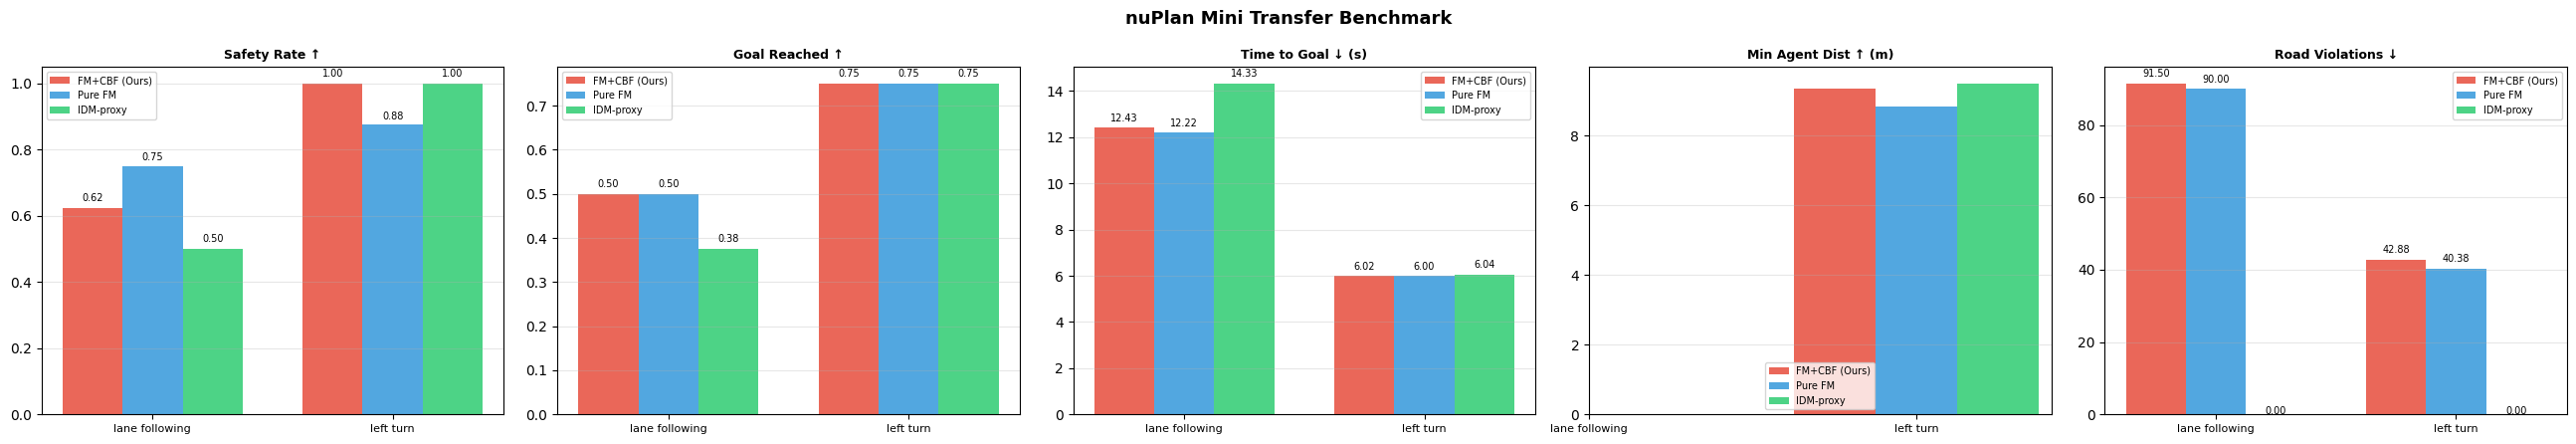

saved: /new_world/cockatiel/ra/safeflow-nuplan-transfer/dmpc_fm_cbf/notebooks/cache/nuplan_transfer/summary_barplots.png


In [8]:
# ── Summary metrics table & bar charts ──────────────────────────────────
if len(metrics_df) == 0:
    raise RuntimeError('No results. Check model path and scenario loading.')

summary_df = (
    metrics_df
    .groupby(['paper_bucket','method'], as_index=False)
    .agg(
        time_to_goal_s         =('time_to_goal_s','mean'),
        collision_rate         =('collision','mean'),
        safety_rate            =('collision', lambda x: 1.-float(np.mean(x))),
        goal_reached_rate      =('goal_reached','mean'),
        min_inter_agent_dist_m =('min_inter_agent_dist_m','mean'),
        road_boundary_violations=('road_boundary_violations','mean'),
        final_dist_to_goal_m   =('final_dist_to_goal_m','mean'),
        episodes               =('method','count'),
    )
    .sort_values(['paper_bucket','method'])
)
summary_df.to_csv(OUTPUT_DIR/'summary_metrics.csv', index=False)
display(summary_df)

METHOD_COLORS = {'fm_cbf':'#e74c3c','pure_fm':'#3498db','idm_proxy':'#2ecc71'}
METHOD_LABELS = {'fm_cbf':'FM+CBF (Ours)','pure_fm':'Pure FM','idm_proxy':'IDM-proxy'}

fig, axes = plt.subplots(1, 5, figsize=(26, 4.5))
plot_specs = [
    ('safety_rate',             'Safety Rate ↑'),
    ('goal_reached_rate',       'Goal Reached ↑'),
    ('time_to_goal_s',          'Time to Goal ↓ (s)'),
    ('min_inter_agent_dist_m',  'Min Agent Dist ↑ (m)'),
    ('road_boundary_violations','Road Violations ↓'),
]
buckets = sorted(summary_df['paper_bucket'].unique())
x = np.arange(len(buckets)); w = 0.25

for ax, (metric, title) in zip(axes, plot_specs):
    for mi, method in enumerate(CFG.methods):
        vals = [summary_df[(summary_df.paper_bucket==b)&
                           (summary_df.method==method)][metric].values
                for b in buckets]
        vals = [float(v[0]) if len(v) else 0. for v in vals]
        bars = ax.bar(x + mi*w, vals, w,
                      label=METHOD_LABELS.get(method,method),
                      color=METHOD_COLORS.get(method,'#aaaaaa'),
                      alpha=0.85)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height()+max(vals)*0.02+1e-9,
                    f'{v:.2f}', ha='center', fontsize=7)
    ax.set_xticks(x + w)
    ax.set_xticklabels([b.replace('_',' ') for b in buckets], fontsize=8)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.3)

plt.suptitle('nuPlan Mini Transfer Benchmark', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(OUTPUT_DIR/'summary_barplots.png', dpi=180, bbox_inches='tight')
plt.show()
print('saved:', OUTPUT_DIR/'summary_barplots.png')


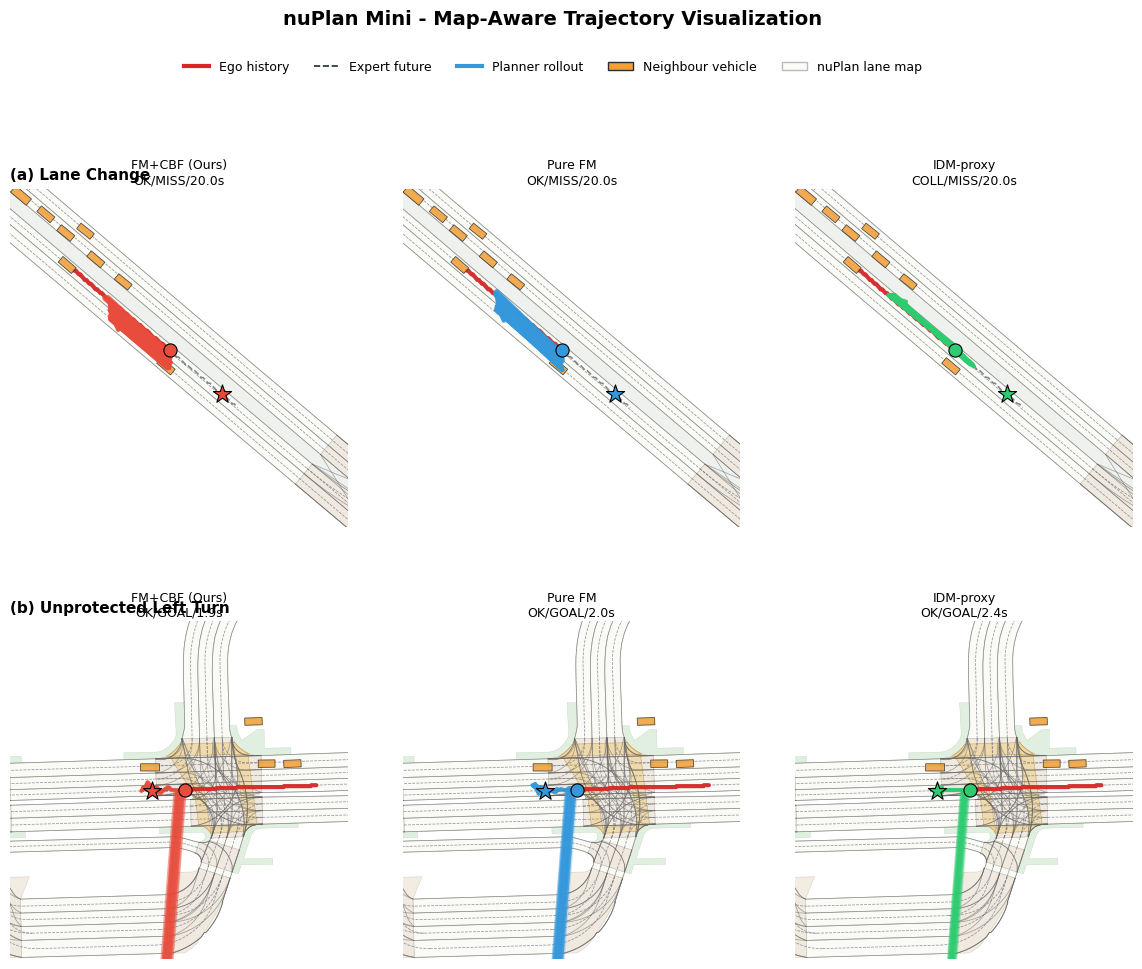

saved: /new_world/cockatiel/ra/safeflow-nuplan-transfer/dmpc_fm_cbf/notebooks/cache/nuplan_transfer/trajectory_fig3_map.png


In [9]:
# ── Trajectory visualization with real nuPlan map scenery ───────────────

def _ensure_setup():
    """Rebuild all visualization dependencies when setup cells haven't been run."""
    import random, sqlite3
    from dataclasses import dataclass
    from pathlib import Path
    from typing import Dict, Optional, Tuple
    import numpy as np
    g = globals()
    ROOT = Path('/new_world/cockatiel/ra').resolve()
    PROJ = ROOT / 'safeflow-nuplan-transfer' / 'dmpc_fm_cbf'
    DATA_ROOT       = ROOT / 'data' / 'cache' / 'mini'
    g['MAP_ROOT']   = ROOT / 'maps'
    g['OUTPUT_DIR'] = PROJ / 'notebooks' / 'cache' / 'nuplan_transfer'

    @dataclass
    class ScenarioRecord:
        db_path: Path; scene_token: bytes; anchor_lidar_pc_token: bytes
        goal_ego_pose_token: Optional[bytes]; scenario_tag: str
        paper_bucket: str; scene_name: str; location: str; map_version: str

    @dataclass
    class BenchmarkConfig:
        seed: int = 7; scenarios_per_type: int = 8
        replay_dt_fallback: float = 0.1; max_agents: int = 8
        goal_tol_m: float = 8.0
        methods: Tuple[str,...] = ('fm_cbf','pure_fm','idm_proxy')
        scenario_type_map: Dict[str,str] = None
        def __post_init__(self):
            if self.scenario_type_map is None:
                self.scenario_type_map = {
                    'lane_following': 'following_lane_without_lead',
                    'left_turn':      'starting_left_turn',
                }

    cfg = BenchmarkConfig()
    g['CFG'] = cfg

    def _blob_hex(b): return None if b is None else b.hex()
    def _yaw(qw,qx,qy,qz):
        return float(np.arctan2(2.0*(qw*qz+qx*qy), 1.0-2.0*(qy*qy+qz*qz)))

    def _discover(cfg):
        records = []
        for db_path in sorted(DATA_ROOT.glob('*.db')):
            try:
                with sqlite3.connect(str(db_path)) as con:
                    cur = con.cursor()
                    row = cur.execute('SELECT location,map_version FROM log LIMIT 1').fetchone()
                    loc,mv = row if row else ('unknown','unknown')
                    for bucket,tag in cfg.scenario_type_map.items():
                        for st,at,gt,sn,sc in cur.execute('''
                            SELECT DISTINCT lp.scene_token,st2.lidar_pc_token,
                                   s.goal_ego_pose_token,s.name,st2.type
                            FROM scenario_tag st2
                            JOIN lidar_pc lp ON st2.lidar_pc_token=lp.token
                            JOIN scene s ON lp.scene_token=s.token
                            WHERE st2.type=? ORDER BY s.name''',(tag,)).fetchall():
                            records.append(ScenarioRecord(db_path=db_path,
                                scene_token=st,anchor_lidar_pc_token=at,
                                goal_ego_pose_token=gt,scenario_tag=sc,
                                paper_bucket=bucket,scene_name=sn,location=loc,map_version=mv))
            except sqlite3.DatabaseError: pass
        return records

    def _sample(records, cfg):
        rng = random.Random(cfg.seed)
        chosen = []
        for bucket in cfg.scenario_type_map:
            pool = [r for r in records if r.paper_bucket==bucket]
            rng.shuffle(pool); chosen.extend(pool[:cfg.scenarios_per_type])
        return chosen

    def _load_bundle(record, cfg):
        con = sqlite3.connect(str(record.db_path)); cur = con.cursor()
        frame_rows = cur.execute('''
            SELECT lp.token,lp.timestamp,ep.x,ep.y,ep.qw,ep.qx,ep.qy,ep.qz,ep.vx,ep.vy
            FROM lidar_pc lp JOIN ego_pose ep ON lp.ego_pose_token=ep.token
            WHERE lp.scene_token=? ORDER BY lp.timestamp''',(record.scene_token,)).fetchall()
        goal_xy = None
        if record.goal_ego_pose_token is not None:
            r = cur.execute('SELECT x,y FROM ego_pose WHERE token=?',
                            (record.goal_ego_pose_token,)).fetchone()
            if r: goal_xy = np.array(r,np.float32)
        frames=[]; last_ts=None
        for token,ts,x,y,qw,qx,qy,qz,vx,vy in frame_rows:
            dt = cfg.replay_dt_fallback if last_ts is None else max((ts-last_ts)*1e-6,1e-3)
            last_ts=ts
            agents=[{'track_token':tr,'xy':np.array([ax,ay],np.float32),
                     'vx':float(avx),'vy':float(avy),'yaw':float(ayaw),
                     'width':float(w),'length':float(l),'category':cat}
                    for tr,ax,ay,avx,avy,ayaw,w,l,cat in cur.execute('''
                        SELECT lb.track_token,lb.x,lb.y,lb.vx,lb.vy,
                               lb.yaw,lb.width,lb.length,c.name
                        FROM lidar_box lb JOIN track t ON lb.track_token=t.token
                        JOIN category c ON t.category_token=c.token
                        WHERE lb.lidar_pc_token=? AND c.name='vehicle' ''',(token,)).fetchall()]
            frames.append({'lidar_pc_token':token,'timestamp':ts,'dt':dt,
                           'ego_x':float(x),'ego_y':float(y),'ego_yaw':_yaw(qw,qx,qy,qz),
                           'ego_vx':float(vx),'ego_vy':float(vy),'agents':agents})
        con.close()
        anchor_idx = next(i for i,f in enumerate(frames)
                          if f['lidar_pc_token']==record.anchor_lidar_pc_token)
        goal_frame = min(anchor_idx+80, len(frames)-1)
        if goal_xy is None:
            goal_xy = np.array([frames[goal_frame]['ego_x'],
                                frames[goal_frame]['ego_y']],np.float32)
        corridor = np.array([[f['ego_x'],f['ego_y']] for f in frames[anchor_idx:]],np.float32)
        history  = np.array([[f['ego_x'],f['ego_y']] for f in frames[:anchor_idx+1]],np.float32)
        return {'record':record,'frames':frames,'anchor_index':anchor_idx,
                'goal_xy':goal_xy,'corridor_xy':corridor,'history_xy':history}

    _cache={}
    def get_scene_bundle(record,cfg):
        key=(str(record.db_path),_blob_hex(record.anchor_lidar_pc_token))
        if key not in _cache: _cache[key]=_load_bundle(record,cfg)
        return _cache[key]
    g['get_scene_bundle']=get_scene_bundle; g['SCENE_CACHE']=_cache

    random.seed(cfg.seed); np.random.seed(cfg.seed)
    print('[setup] discovering scenarios ...')
    all_s=_discover(cfg); g['ALL_SCENARIOS']=all_s
    g['SELECTED_SCENARIOS']=_sample(all_s,cfg)
    print(f'[setup] {len(g["SELECTED_SCENARIOS"])} scenarios ready')
    g['METHOD_COLORS']={'fm_cbf':'#e74c3c','pure_fm':'#3498db','idm_proxy':'#2ecc71'}
    g['METHOD_LABELS']={'fm_cbf':'FM+CBF (Ours)','pure_fm':'Pure FM','idm_proxy':'IDM-proxy'}


# ── Restore kernel state from cache if needed ────────────────────────────
try:
    traces_df; metrics_df
except NameError:
    from pathlib import Path; import pandas as pd
    try: _out = OUTPUT_DIR
    except NameError:
        _out = Path('/new_world/cockatiel/ra/safeflow-nuplan-transfer/dmpc_fm_cbf/notebooks/cache/nuplan_transfer')
    _tc,_mc = _out/'traces.csv', _out/'metrics.csv'
    if not _tc.exists(): raise RuntimeError('No traces. Run benchmark cell first.')
    traces_df=pd.read_csv(_tc); metrics_df=pd.read_csv(_mc)
    print(f'[loaded from cache] {len(traces_df)} trace rows')

try:
    SELECTED_SCENARIOS; CFG; get_scene_bundle; METHOD_COLORS; METHOD_LABELS; MAP_ROOT
except NameError:
    _ensure_setup()

if len(traces_df)==0:
    raise RuntimeError('No traces. Run benchmark cell first.')

import geopandas as gpd
from pyproj import Transformer
from shapely.geometry import (GeometryCollection, LineString,
                               MultiLineString, MultiPolygon, Polygon)
from matplotlib.patches import Rectangle
from matplotlib.transforms import Affine2D

BUCKET_TITLES = {
    'lane_following': '(a) Lane Change',
    'left_turn':      '(b) Unprotected Left Turn',
}

MAP_LAYER_STYLES = [
    ('generic_drivable_areas', dict(facecolor='#eef1ec',edgecolor='none',linewidth=0.0,alpha=0.95,zorder=0)),
    ('road_segments',          dict(facecolor='#f4f5f1',edgecolor='#d4d8cf',linewidth=0.35,alpha=0.95,zorder=1)),
    ('lanes_polygons',         dict(facecolor='#fbfbf7',edgecolor='#b8beb6',linewidth=0.45,alpha=0.96,zorder=2)),
    ('gen_lane_connectors_scaled_width_polygons',
                               dict(facecolor='#f7f7f2',edgecolor='#c7ccc3',linewidth=0.35,alpha=0.90,zorder=2)),
    ('intersections',          dict(facecolor='#ede4d7',edgecolor='#cbbba6',linewidth=0.35,alpha=0.70,zorder=3)),
    ('crosswalks',             dict(facecolor='#f1d59c',edgecolor='#bd9448',linewidth=0.40,alpha=0.78,zorder=4)),
    ('walkways',               dict(facecolor='#d8ead6',edgecolor='#b7d0b4',linewidth=0.30,alpha=0.75,zorder=1)),
    ('baseline_paths',         dict(color='#6f7782',linewidth=0.55,alpha=0.75,linestyle='--',zorder=5)),
    ('boundaries',             dict(color='#666666',linewidth=0.55,alpha=0.55,linestyle='-',zorder=6)),
]
_MAPVER_TO_CRS = {
    'us-nv-las-vegas-strip':      'epsg:32611',
    'us-pa-pittsburgh-hazelwood': 'epsg:32617',
    'us-ma-boston':               'epsg:32619',
    'sg-one-north':               'epsg:32648',
}
_MAP_CACHE = {}


def map_gpkg_for_record(record):
    candidates = []
    candidates += sorted((MAP_ROOT/str(record.map_version)).glob('*/map.gpkg'))
    candidates += sorted((MAP_ROOT/str(record.location)).glob('*/map.gpkg'))
    if not candidates:
        raise FileNotFoundError(
            f'No map.gpkg for location={record.location}, map_version={record.map_version}')
    return candidates[0]


def map_meta(gpkg_path):
    key=('meta',str(gpkg_path))
    if key not in _MAP_CACHE:
        meta_df=gpd.read_file(gpkg_path,layer='meta')
        _MAP_CACHE[key]=dict(zip(meta_df['key'],meta_df['value']))
    return _MAP_CACHE[key]


def projected_bounds_to_geo(bounds_proj, projected_crs, geographic_crs='epsg:4326'):
    minx,miny,maxx,maxy=[float(v) for v in bounds_proj]
    t=Transformer.from_crs(projected_crs,geographic_crs,always_xy=True)
    corners=[(minx,miny),(minx,maxy),(maxx,miny),(maxx,maxy)]
    lonlat=np.array([t.transform(x,y) for x,y in corners],dtype=np.float64)
    return (float(lonlat[:,0].min()),float(lonlat[:,1].min()),
            float(lonlat[:,0].max()),float(lonlat[:,1].max()))


def load_map_layer(gpkg_path, layer, bounds_proj, map_version=''):
    meta=map_meta(gpkg_path)
    projected_crs=(meta.get('projectedCoordSystem')
                   or _MAPVER_TO_CRS.get(map_version, 'epsg:32617'))
    geographic_crs=meta.get('geographicCoordSystem','epsg:4326')
    bbox_geo=projected_bounds_to_geo(bounds_proj,projected_crs,geographic_crs)
    rounded=tuple(round(v,2) for v in bounds_proj)
    key=('layer',str(gpkg_path),layer,rounded)
    if key in _MAP_CACHE: return _MAP_CACHE[key]
    try:
        gdf=gpd.read_file(gpkg_path,layer=layer,bbox=bbox_geo)
    except Exception as exc:
        print(f'[map skip] {layer}: {exc}')
        gdf=gpd.GeoDataFrame(geometry=[],crs=geographic_crs)
    if len(gdf) and gdf.crs is None: gdf=gdf.set_crs(geographic_crs)
    if len(gdf): gdf=gdf.to_crs(projected_crs)
    _MAP_CACHE[key]=gdf
    return gdf


def draw_polygon(ax, poly, *, facecolor, edgecolor, linewidth, alpha, zorder):
    xy=np.asarray(poly.exterior.coords)
    ax.fill(xy[:,0],xy[:,1],facecolor=facecolor,edgecolor=edgecolor,
            linewidth=linewidth,alpha=alpha,zorder=zorder)
    for interior in poly.interiors:
        hole=np.asarray(interior.coords)
        ax.fill(hole[:,0],hole[:,1],facecolor=ax.get_facecolor(),
                edgecolor='none',zorder=zorder+0.01)

def draw_line(ax, line, *, color, linewidth, alpha, linestyle, zorder):
    xy=np.asarray(line.coords)
    if len(xy)>1:
        ax.plot(xy[:,0],xy[:,1],color=color,linewidth=linewidth,
                alpha=alpha,linestyle=linestyle,zorder=zorder)

def draw_geometry(ax, geom, style):
    if geom is None or geom.is_empty: return
    if isinstance(geom,Polygon): draw_polygon(ax,geom,**style)
    elif isinstance(geom,MultiPolygon):
        for p in geom.geoms: draw_polygon(ax,p,**style)
    elif isinstance(geom,LineString): draw_line(ax,geom,**style)
    elif isinstance(geom,MultiLineString):
        for l in geom.geoms: draw_line(ax,l,**style)
    elif isinstance(geom,GeometryCollection):
        for c in geom.geoms: draw_geometry(ax,c,style)


def draw_nuplan_map(ax, record, bounds_proj):
    try:
        gpkg_path=map_gpkg_for_record(record)
    except FileNotFoundError as e:
        print(f'[map] missing: {e}')
        ax.set_facecolor('#f0f0f0'); return
    ax.set_facecolor('#f8faf8')
    n_feat=0
    for layer,style in MAP_LAYER_STYLES:
        gdf=load_map_layer(gpkg_path,layer,bounds_proj,record.map_version)
        n_feat+=len(gdf)
        for geom in gdf.geometry:
            draw_geometry(ax,geom,style)
    if n_feat==0:
        print(f'[map] WARNING: 0 features for bounds={tuple(round(b,1) for b in bounds_proj)}')


# ── Fixed viewport centred on anchor, shifted slightly along corridor ────
def scene_bounds_for_plot(bundle, view_half=45.0):
    anchor_idx=bundle['anchor_index']
    anchor_frame=bundle['frames'][anchor_idx]
    cx=float(anchor_frame['ego_x']); cy=float(anchor_frame['ego_y'])
    corridor=np.asarray(bundle.get('corridor_xy',[]),dtype=np.float64)
    if corridor.ndim==2 and len(corridor)>5:
        near=corridor[min(15,len(corridor)-1)]
        d=near-np.array([cx,cy]); dist=float(np.linalg.norm(d))
        if dist>1e-3:
            shift=min(dist*0.35, 12.0)
            cx+=d[0]/dist*shift; cy+=d[1]/dist*shift
    return (cx-view_half, cy-view_half, cx+view_half, cy+view_half)


def draw_agent_box(ax, agent, *, facecolor='#f39c12', edgecolor='#262626',
                   alpha=0.92, zorder=20):
    x,y=float(agent['xy'][0]),float(agent['xy'][1])
    length=float(agent.get('length',4.6)); width=float(agent.get('width',1.9))
    yaw=float(agent.get('yaw',0.0))
    rect=Rectangle((-length/2,-width/2),length,width,
                   facecolor=facecolor,edgecolor=edgecolor,linewidth=0.55,
                   alpha=alpha,zorder=zorder)
    rect.set_transform(Affine2D().rotate(yaw).translate(x,y)+ax.transData)
    ax.add_patch(rect)


def draw_time_gradient_trace(ax, xy, *, color, linewidth=3.0, zorder=30):
    xy=np.asarray(xy,dtype=np.float64)
    if len(xy)<2: return
    for i in range(len(xy)-1):
        alpha=0.25+0.75*(i/max(1,len(xy)-2))
        ax.plot(xy[i:i+2,0],xy[i:i+2,1],color=color,linewidth=linewidth,
                alpha=alpha,solid_capstyle='round',zorder=zorder)
    ax.annotate('',xy=xy[-1],xytext=xy[-2],
                arrowprops=dict(arrowstyle='-|>',color=color,lw=linewidth,alpha=0.95),
                zorder=zorder+1)


buckets=sorted(traces_df['paper_bucket'].unique())
n_methods=len(CFG.methods)
fig,axes=plt.subplots(len(buckets),n_methods,
                      figsize=(5.0*n_methods,5.0*len(buckets)),
                      gridspec_kw=dict(hspace=0.28,wspace=0.04),
                      constrained_layout=False)
if len(buckets)==1: axes=axes[np.newaxis,:]

for row,bucket in enumerate(buckets):
    bucket_traces=traces_df[traces_df['paper_bucket']==bucket]
    def _spread(sn):
        sc=bucket_traces[bucket_traces['scene_name']==sn][['x','y']].to_numpy(float)
        return float((sc.max(0)-sc.min(0)).sum()) if len(sc)>1 else 0.
    scene_name=max(
        bucket_traces['scene_name'].unique(),
        key=lambda s:(bucket_traces[bucket_traces['scene_name']==s]['method'].nunique(),
                      _spread(s)))
    record=next(r for r in SELECTED_SCENARIOS
                if r.scene_name==scene_name and r.paper_bucket==bucket)
    bundle=get_scene_bundle(record,CFG)

    corridor=np.asarray(bundle['corridor_xy'],dtype=np.float64)
    history=np.asarray(bundle['history_xy'],dtype=np.float64)
    anchor_idx=bundle['anchor_index']
    anchor_frame=bundle['frames'][anchor_idx]
    anchor_agents=anchor_frame['agents']
    start_xy=np.array([anchor_frame['ego_x'],anchor_frame['ego_y']],dtype=np.float64)
    bounds=scene_bounds_for_plot(bundle)

    # near goal: corridor point ~30 frames ahead
    near_goal_xy=corridor[min(30,len(corridor)-1)] if len(corridor)>1 else start_xy
    # corridor display: first 40 frames
    corridor_vis=corridor[:min(40,len(corridor))]

    for col,method in enumerate(CFG.methods):
        ax=axes[row,col]
        ax.set_aspect('equal'); ax.axis('off')
        color=METHOD_COLORS.get(method,'#555555')

        draw_nuplan_map(ax,record,bounds)

        if len(corridor_vis)>1:
            ax.plot(corridor_vis[:,0],corridor_vis[:,1],color='#1f2933',linestyle='--',
                    linewidth=1.15,alpha=0.55,zorder=24,label='Expert future')
        if len(history)>1:
            ax.plot(history[:,0],history[:,1],linewidth=3.0,color='#d62728',
                    alpha=0.95,solid_capstyle='round',zorder=25,label='Ego history')
            ax.scatter(history[-1,0],history[-1,1],s=34,color='#d62728',
                       edgecolors='white',linewidths=0.7,zorder=26)

        sc_trace=traces_df[(traces_df['scene_name']==scene_name)&
                           (traces_df['method']==method)].sort_values('step')
        if len(sc_trace)>1:
            # cap at 50 steps to prevent wandering blobs from filling the panel
            draw_time_gradient_trace(ax,sc_trace[['x','y']].to_numpy()[:50],color=color)

        for agent in anchor_agents[:10]:
            draw_agent_box(ax,agent,facecolor='#f2a03a',edgecolor='#2d2d2d',
                           alpha=0.88,zorder=28)
        ax.scatter(start_xy[0],start_xy[1],s=90,marker='o',color=color,
                   edgecolors='black',linewidths=0.8,zorder=36)
        ax.scatter(near_goal_xy[0],near_goal_xy[1],s=190,marker='*',color=color,
                   edgecolors='black',linewidths=0.8,zorder=36)
        ax.set_xlim(bounds[0],bounds[2]); ax.set_ylim(bounds[1],bounds[3])

        m_row=metrics_df[(metrics_df.scene_name==scene_name)&(metrics_df.method==method)]
        safe_sym='OK' if(len(m_row)==0 or m_row['collision'].values[0]==0) else 'COLL'
        goal_sym='GOAL' if(len(m_row)>0 and m_row['goal_reached'].values[0]==1) else 'MISS'
        ttg=f"{m_row['time_to_goal_s'].values[0]:.1f}s" if len(m_row)>0 else 'N/A'
        ax.set_title(f"{METHOD_LABELS.get(method,method)}\n{safe_sym}/{goal_sym}/{ttg}",
                     fontsize=9,pad=4)

    axes[row,0].text(0.0,1.02,BUCKET_TITLES.get(bucket,bucket),
                     transform=axes[row,0].transAxes,fontsize=11,
                     fontweight='bold',ha='left',va='bottom')

legend_handles=[
    plt.Line2D([],[],color='#d62728',lw=3,label='Ego history'),
    plt.Line2D([],[],color='#1f2933',lw=1.2,ls='--',label='Expert future'),
    plt.Line2D([],[],color='#3498db',lw=3,label='Planner rollout'),
    mpatches.Patch(facecolor='#f2a03a',edgecolor='#2d2d2d',label='Neighbour vehicle'),
    mpatches.Patch(facecolor='#fbfbf7',edgecolor='#b8beb6',label='nuPlan lane map'),
]
fig.legend(handles=legend_handles,loc='upper center',ncol=5,
           bbox_to_anchor=(0.5,1.02),fontsize=9,frameon=False)
plt.suptitle('nuPlan Mini - Map-Aware Trajectory Visualization',
             fontsize=14,fontweight='bold',y=1.06)
out_path=OUTPUT_DIR/'trajectory_fig3_map.png'
fig.savefig(out_path,dpi=220,bbox_inches='tight')
plt.show()
print('saved:',out_path)


TypeError: _dpoly() got an unexpected keyword argument 'facecolor'

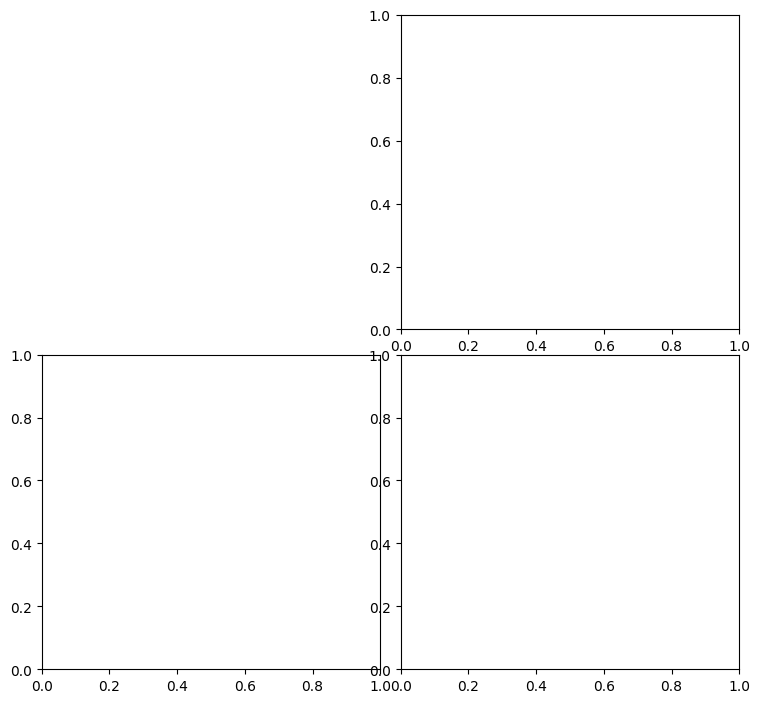

In [10]:
# ── Paper figure: 2 methods × 2 scenarios, compact map style ────────────
# Layout mirrors reference Fig3: row = method, col = scenario

import geopandas as gpd
from pyproj import Transformer
from shapely.geometry import (GeometryCollection, LineString,
                               MultiLineString, MultiPolygon, Polygon)
from matplotlib.patches import Rectangle
from matplotlib.transforms import Affine2D

try:
    SELECTED_SCENARIOS; CFG; get_scene_bundle; MAP_ROOT
    traces_df; metrics_df
except NameError:
    _ensure_setup()
    from pathlib import Path; import pandas as pd
    _out = Path('/new_world/cockatiel/ra/safeflow-nuplan-transfer/dmpc_fm_cbf/notebooks/cache/nuplan_transfer')
    traces_df  = pd.read_csv(_out / 'traces.csv')
    metrics_df = pd.read_csv(_out / 'metrics.csv')

# ── clean minimal map palette ────────────────────────────────────────────
_CLEAN_MAP_LAYERS = [
    ('generic_drivable_areas',
     dict(facecolor='#dfe8de', edgecolor='none', linewidth=0, alpha=1.0, zorder=0)),
    ('road_segments',
     dict(facecolor='#eef0eb', edgecolor='#c2c8bf', linewidth=0.3, alpha=1.0, zorder=1)),
    ('lanes_polygons',
     dict(facecolor='#f8f8f4', edgecolor='#adb5ab', linewidth=0.45, alpha=1.0, zorder=2)),
    ('gen_lane_connectors_scaled_width_polygons',
     dict(facecolor='#f4f4ef', edgecolor='#c0c5be', linewidth=0.3, alpha=0.9, zorder=2)),
    ('intersections',
     dict(facecolor='#e8dfd0', edgecolor='none', linewidth=0, alpha=0.75, zorder=3)),
    ('crosswalks',
     dict(facecolor='#edd898', edgecolor='#b89040', linewidth=0.35, alpha=0.7, zorder=4)),
    ('baseline_paths',
     dict(color='#808898', linewidth=0.45, alpha=0.55, linestyle='--', zorder=5)),
    ('boundaries',
     dict(color='#606870', linewidth=0.45, alpha=0.45, linestyle='-', zorder=6)),
]
_MAPVER_TO_CRS = {
    'us-nv-las-vegas-strip':      'epsg:32611',
    'us-pa-pittsburgh-hazelwood': 'epsg:32617',
    'us-ma-boston':               'epsg:32619',
    'sg-one-north':               'epsg:32648',
}
_FIG_MAP_CACHE = {}

def _fig_map_gpkg(record):
    for base in [MAP_ROOT/str(record.map_version), MAP_ROOT/str(record.location)]:
        cands = sorted(base.glob('*/map.gpkg'))
        if cands: return cands[0]
    raise FileNotFoundError(f'no map for {record.location}/{record.map_version}')

def _fig_map_meta(gpkg):
    k = ('fmeta', str(gpkg))
    if k not in _FIG_MAP_CACHE:
        m = gpd.read_file(gpkg, layer='meta')
        _FIG_MAP_CACHE[k] = dict(zip(m['key'], m['value']))
    return _FIG_MAP_CACHE[k]

def _proj2geo(bounds, proj, geo='epsg:4326'):
    t = Transformer.from_crs(proj, geo, always_xy=True)
    pts = [(bounds[0],bounds[1]),(bounds[0],bounds[3]),
           (bounds[2],bounds[1]),(bounds[2],bounds[3])]
    ll  = np.array([t.transform(x,y) for x,y in pts])
    return float(ll[:,0].min()), float(ll[:,1].min()), float(ll[:,0].max()), float(ll[:,1].max())

def _load_fig_layer(gpkg, layer, bounds, map_version=''):
    meta = _fig_map_meta(gpkg)
    proj = (meta.get('projectedCoordSystem')
            or _MAPVER_TO_CRS.get(map_version, 'epsg:32617'))
    geo  = meta.get('geographicCoordSystem', 'epsg:4326')
    bbox = _proj2geo(bounds, proj, geo)
    k = ('fl', str(gpkg), layer, tuple(round(v,1) for v in bounds))
    if k in _FIG_MAP_CACHE: return _FIG_MAP_CACHE[k]
    try:
        gdf = gpd.read_file(gpkg, layer=layer, bbox=bbox)
    except Exception:
        gdf = gpd.GeoDataFrame(geometry=[], crs=geo)
    if len(gdf):
        if gdf.crs is None: gdf = gdf.set_crs(geo)
        gdf = gdf.to_crs(proj)
    _FIG_MAP_CACHE[k] = gdf
    return gdf

def _dpoly(ax, poly, fc, ec, lw, alpha, zorder):
    xy = np.asarray(poly.exterior.coords)
    ax.fill(xy[:,0], xy[:,1], fc=fc, ec=ec, lw=lw, alpha=alpha, zorder=zorder)
    for h in poly.interiors:
        hxy = np.asarray(h.coords)
        ax.fill(hxy[:,0], hxy[:,1], fc=ax.get_facecolor(), ec='none', zorder=zorder+0.01)

def _dline(ax, line, color, lw, alpha, ls, zorder):
    xy = np.asarray(line.coords)
    if len(xy) > 1: ax.plot(xy[:,0], xy[:,1], c=color, lw=lw, alpha=alpha, ls=ls, zorder=zorder)

def _dgeom(ax, geom, style):
    if geom is None or geom.is_empty: return
    if isinstance(geom, Polygon):         _dpoly(ax, geom, **style)
    elif isinstance(geom, MultiPolygon):  [_dpoly(ax, p, **style) for p in geom.geoms]
    elif isinstance(geom, LineString):    _dline(ax, geom, **style)
    elif isinstance(geom, MultiLineString): [_dline(ax, l, **style) for l in geom.geoms]
    elif isinstance(geom, GeometryCollection): [_dgeom(ax, c, style) for c in geom.geoms]

def draw_clean_map(ax, record, bounds):
    try: gpkg = _fig_map_gpkg(record)
    except FileNotFoundError:
        ax.set_facecolor('#e8e8e8'); return
    ax.set_facecolor('#dfe8de')
    for layer, style in _CLEAN_MAP_LAYERS:
        for geom in _load_fig_layer(gpkg, layer, bounds, record.map_version).geometry:
            _dgeom(ax, geom, style)

def fig_bounds(bundle, view_half=42.0):
    af = bundle['frames'][bundle['anchor_index']]
    cx, cy = float(af['ego_x']), float(af['ego_y'])
    cor = np.asarray(bundle['corridor_xy'], np.float64)
    if cor.ndim == 2 and len(cor) > 5:
        near = cor[min(12, len(cor)-1)]
        d = near - np.array([cx, cy]); dist = float(np.linalg.norm(d))
        if dist > 1e-3:
            s = min(dist*0.3, 10.0)
            cx += d[0]/dist*s; cy += d[1]/dist*s
    return (cx-view_half, cy-view_half, cx+view_half, cy+view_half)

# ── figure setup ─────────────────────────────────────────────────────────
METHOD_ORDER  = ['idm_proxy', 'fm_cbf']
METHOD_LABEL  = {'idm_proxy': 'IDM-proxy', 'fm_cbf': 'Flow Planner (ours)'}
BUCKET_ORDER  = ['lane_following', 'left_turn']
BUCKET_LABEL  = {'lane_following': '(a) Lane Change',
                 'left_turn':      '(b) Unprotected Left Turn'}
COLOR_MAP     = {'idm_proxy': '#27ae60', 'fm_cbf': '#e74c3c'}
HIST_COLOR    = '#8b1a1a'

fig, axes = plt.subplots(2, 2, figsize=(9.0, 8.5),
                          gridspec_kw=dict(hspace=0.08, wspace=0.06))

for col, bucket in enumerate(BUCKET_ORDER):
    bt = traces_df[traces_df['paper_bucket'] == bucket]
    def _spread10(sn):
        sc=bt[bt['scene_name']==sn][['x','y']].to_numpy(float)
        return float((sc.max(0)-sc.min(0)).sum()) if len(sc)>1 else 0.
    scene_name=max(
        bt['scene_name'].unique(),
        key=lambda s:(bt[bt['scene_name']==s]['method'].nunique(), _spread10(s)))
    record = next(r for r in SELECTED_SCENARIOS
                  if r.scene_name==scene_name and r.paper_bucket==bucket)
    bundle = get_scene_bundle(record, CFG)
    bounds = fig_bounds(bundle)

    corridor = np.asarray(bundle['corridor_xy'], np.float64)
    history  = np.asarray(bundle['history_xy'],  np.float64)
    af       = bundle['frames'][bundle['anchor_index']]
    start_xy = np.array([af['ego_x'], af['ego_y']], np.float64)
    agents   = af['agents']
    near_goal= corridor[min(28, len(corridor)-1)] if len(corridor)>1 else start_xy
    cor_vis  = corridor[:min(35, len(corridor))]

    for row, method in enumerate(METHOD_ORDER):
        ax = axes[row, col]
        ax.set_aspect('equal'); ax.axis('off')
        color = COLOR_MAP[method]

        draw_clean_map(ax, record, bounds)

        # expert corridor (dashed, light)
        if len(cor_vis) > 1:
            ax.plot(cor_vis[:,0], cor_vis[:,1],
                    color='#3a4a5a', lw=1.1, ls='--', alpha=0.45, zorder=20)

        # ego history
        if len(history) > 1:
            hv = history[-min(15, len(history)):]
            ax.plot(hv[:,0], hv[:,1], color=HIST_COLOR,
                    lw=2.2, alpha=0.88, solid_capstyle='round', zorder=25)
            ax.scatter(hv[-1,0], hv[-1,1], s=24, color=HIST_COLOR,
                       edgecolors='white', linewidths=0.6, zorder=26)

        # planner rollout (capped at 50 steps)
        sc = bt[(bt['scene_name']==scene_name)&(bt['method']==method)].sort_values('step')
        if len(sc) > 1:
            txy = sc[['x','y']].values[:50]
            for i in range(len(txy)-1):
                a = 0.28 + 0.72*(i / max(1, len(txy)-2))
                ax.plot(txy[i:i+2,0], txy[i:i+2,1],
                        color=color, lw=2.6, alpha=a,
                        solid_capstyle='round', zorder=30)
            ax.annotate('', xy=txy[-1], xytext=txy[-2],
                        arrowprops=dict(arrowstyle='-|>',
                                        color=color, lw=2.6, alpha=0.96),
                        zorder=31)

        # neighbour vehicles
        for agent in agents[:10]:
            x, y = float(agent['xy'][0]), float(agent['xy'][1])
            L = float(agent.get('length', 4.6)); W = float(agent.get('width', 1.9))
            rect = Rectangle((-L/2, -W/2), L, W,
                             facecolor='#f0a028', edgecolor='#282828',
                             linewidth=0.55, alpha=0.88, zorder=28)
            rect.set_transform(Affine2D().rotate(float(agent.get('yaw',0)))
                                         .translate(x, y) + ax.transData)
            ax.add_patch(rect)

        # ego start (circle) and near-goal (star)
        ax.scatter(start_xy[0], start_xy[1], s=75, marker='o', color=color,
                   edgecolors='k', linewidths=0.8, zorder=36)
        ax.scatter(near_goal[0], near_goal[1], s=165, marker='*', color=color,
                   edgecolors='k', linewidths=0.7, zorder=36)

        ax.set_xlim(bounds[0], bounds[2]); ax.set_ylim(bounds[1], bounds[3])

        # column header (top row only)
        if row == 0:
            ax.set_title(BUCKET_LABEL[bucket], fontsize=11,
                         fontweight='bold', pad=7)

    # row label on the left
    axes[row, 0].set_ylabel('')          # suppress default
for row, method in enumerate(METHOD_ORDER):
    axes[row, 0].annotate(
        METHOD_LABEL[method], xy=(0, 0.5),
        xycoords='axes fraction', xytext=(-8, 0),
        textcoords='offset points', fontsize=10, fontweight='bold',
        ha='right', va='center', rotation=90)

# ── legend ───────────────────────────────────────────────────────────────
import matplotlib.patches as mpatches
legend_handles = [
    plt.Line2D([],[],color=HIST_COLOR,  lw=2.2,          label='Ego history'),
    plt.Line2D([],[],color='#3a4a5a',   lw=1.1, ls='--', label='Expert future'),
    plt.Line2D([],[],color='#e74c3c',   lw=2.6,          label='Flow Planner rollout'),
    plt.Line2D([],[],color='#27ae60',   lw=2.6,          label='IDM-proxy rollout'),
    mpatches.Patch(fc='#f0a028', ec='#282828',            label='Neighbour vehicle'),
    mpatches.Patch(fc='#f8f8f4', ec='#adb5ab',            label='nuPlan lane map'),
]
fig.legend(handles=legend_handles, loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, 1.03), fontsize=8.5, frameon=False,
           columnspacing=1.2)

plt.suptitle('nuPlan Mini — Closed-Loop Trajectory Visualization',
             fontsize=13, fontweight='bold', y=1.08)

out_fig = Path('/new_world/cockatiel/ra/safeflow-nuplan-transfer/dmpc_fm_cbf/notebooks/cache/nuplan_transfer/trajectory_paper_fig.png')
fig.savefig(out_fig, dpi=220, bbox_inches='tight')
plt.show()
print('saved:', out_fig)
